# 14. Descriptive macroeconomic co-movement

Estimate transparent HAC regressions of balance ratios on nominal GDP growth for the full period, plus a small historical labour-market specification, and state plainly what these estimates are not.

**Reads**

- `outputs/tables/nominal_gdp_balance_comovement.csv`
- `outputs/tables/historical_ssf_labour_comovement.csv`
- `data/processed/macro_panel_1977_2025.csv`

**Writes**

- Nothing. Both regression tables are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 15

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Full-period specification

For each subsector,

$$B_{i,t}/GDP_t = \alpha_i + \beta_i g^{nominal}_t + \gamma_i I(t \ge 1995) + \epsilon_{i,t},$$

with HAC standard errors. Nominal GDP growth is used because it is the one
macroeconomic variable reconstructible on a consistent basis from the bundled
sources across the whole 1977-2025 span. The regime dummy absorbs the level
difference between the two statistical vintages; it is not an economic effect.

In [2]:
nominal = pd.read_csv(TABLES / 'nominal_gdp_balance_comovement.csv')
display(nominal.round(4))

,sector,n,r_squared,nominal_gdp_growth_coef,nominal_gdp_growth_se_hac,nominal_gdp_growth_pvalue_hac,modern_regime_coef
0,general_government,48,0.1751,7.7012,8.8215,0.3827,3.6653
1,central_government,48,0.1634,5.5312,7.6465,0.4695,2.8982
2,regional_local_government,48,0.0807,-0.0090,0.8348,0.9914,0.2213
3,social_security_funds,48,0.0707,2.1789,2.0029,0.2766,0.5458


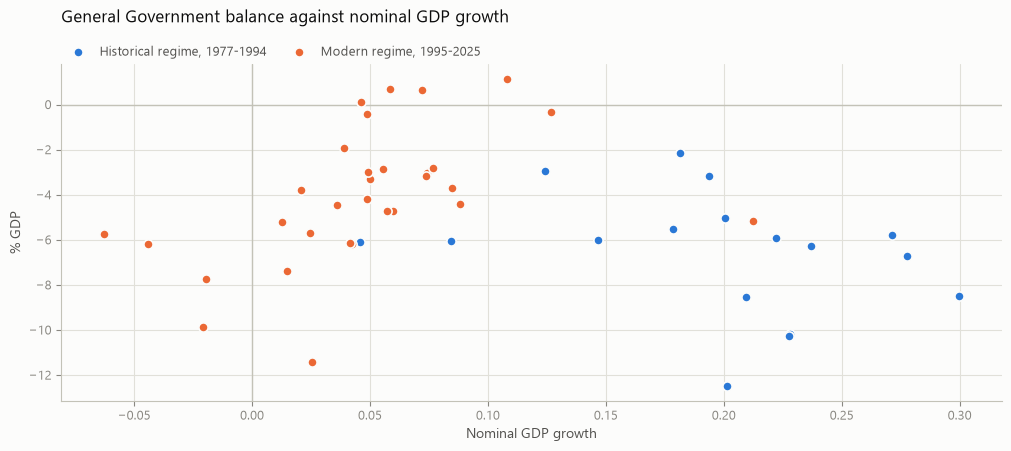

In [3]:
macro = pd.read_csv(PROCESSED / 'macro_panel_1977_2025.csv')
figure = figures.nominal_growth_scatter(macro, sector='general_government')

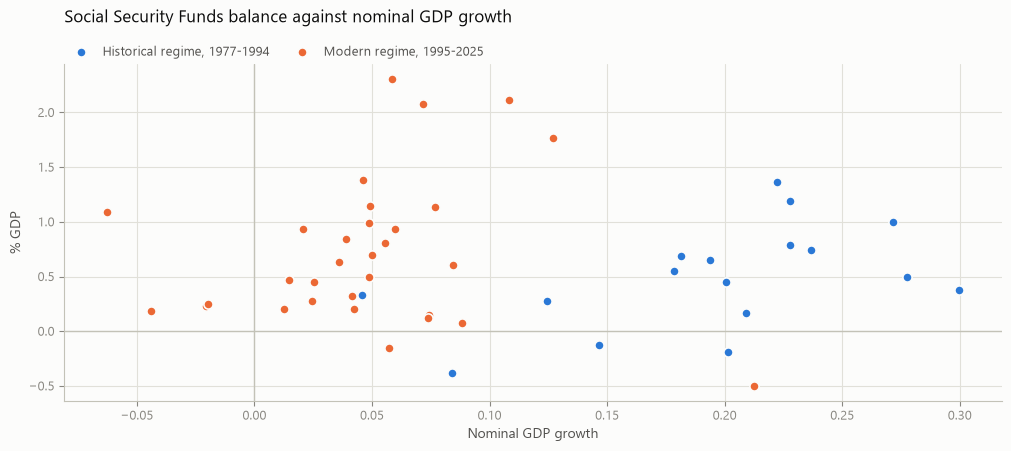

In [4]:
figure = figures.nominal_growth_scatter(macro, sector='social_security_funds')

The scatter plots show why the coefficient should be read as co-movement only:
the two regimes occupy different regions of the growth axis, because the
historical period combines high inflation with high nominal growth.

## 2. Historical labour-market specification

For 1978-1995 the historical workbook also supports a small Social Security
specification using employment growth and the unemployment rate.

In [5]:
labour = pd.read_csv(TABLES / 'historical_ssf_labour_comovement.csv')
display(labour.T.rename(columns={0: 'estimate'}).round(4))

,estimate
n,18.0000
r_squared,0.2494
employment_growth_coef,9.7252
employment_growth_se_hac,5.2069
employment_growth_pvalue_hac,0.0618
unemployment_rate_coef,20.2847
unemployment_rate_se_hac,8.5997
unemployment_rate_pvalue_hac,0.0183


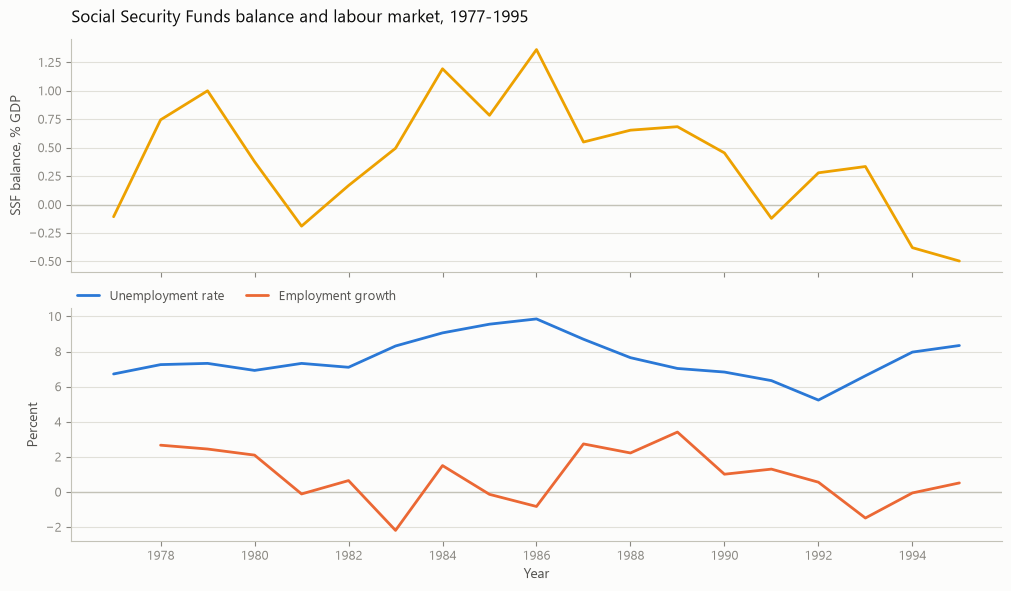

In [6]:
figure = figures.historical_labour_context(macro)

## Interpretation limits

1. **Nominal GDP growth is not an output gap.** Nothing here is a cyclically
   adjusted or structural balance.
2. These are **descriptive co-movement estimates**, not causal effects. No
   identification strategy is claimed and none is implied.
3. The sample is **short and serially correlated**. HAC standard errors address
   the inference arithmetic, not the small-sample or specification risk.
4. The regime dummy is a **statistical control for the 1995 splice**, not an
   estimate of a policy change.
5. The labour specification covers **18 observations**. It is reported for
   transparency and should not carry analytical weight on its own.

---

[Previous: 13. Debt and stock-flow reconciliation](13_debt_reconciliation.ipynb) | [Next: 15. European benchmark](15_european_benchmark.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```